In [13]:
# Week 1: Image Feature Extraction and Dataset Creation
# This section extracts computational image features from four image categories (messy desks, streets, landscapes, and simple rooms). These features will later be used to predict human visual complexity ratings.

import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Path to image dataset folder
base_path="../data/images"

In [15]:
categories = os.listdir(base_path)
clean_categories = []

for item in categories:
    item_path = os.path.join(base_path, item)

    if os.path.isdir(item_path):
        clean_categories.append(item)

print(clean_categories)

['messydesk', 'streets', 'landscape', 'simpleroom']


In [26]:
#Count Images in Each Category
for category in clean_categories:
    category_path = os.path.join(base_path, category)

    image_count = len([
        f for f in os.listdir(category_path)
        if f.lower().endswith(".jpg")
    ])

    print(category, ":", image_count, "images")

messydesk : 20 images
streets : 20 images
landscape : 20 images
simpleroom : 20 images


In [29]:
total_images = 0

for category in clean_categories:
    category_path = os.path.join(base_path, category)

    image_count = len([
        f for f in os.listdir(category_path)
        if f.lower().endswith(".jpg")
    ])

    total_images += image_count

print("Total images:", total_images)

Total images: 80


In [28]:
#Extract Image Features: For each image, we compute three low-level visual features that may relate to perceived visual complexity: edge density, brightness, and color variance.
data=[]

valid_ext=(".jpg")

for category in clean_categories:
    category_path = os.path.join(base_path, category)
    
    for img_name in os.listdir(category_path):
        if not img_name.lower().endswith(valid_ext):
            continue

        img_path=os.path.join(category_path, img_name)

        #load image into memory
        img=cv2.imread(img_path)
        
        if img is None:
            print("Broken image:", img_path)
            continue

        # Convert color image to grayscale
        gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Detect edges
        edges=cv2.Canny(gray, 100, 200)

        # Calculate edge density
        edge_density=np.mean(edges>0)

        #brightness
        brightness=np.mean(gray)

        #color variance
        color_var=np.var(img)
        
        data.append({"image":img_name, "category": category, "edge_density": edge_density, "brightness": brightness, "color_var": color_var})

df = pd.DataFrame(data)

# Assign Researcher Complexity Ratings
researcher_scores = {
    # messydesk
    "messydesk1.jpg": 4,
    "messydesk2.jpg": 3,
    "messydesk3.jpg": 2,
    "messydesk4.jpg": 4,
    "messydesk5.jpg": 5,
    "messydesk6.jpg": 4,
    "messydesk7.jpg": 3,
    "messydesk8.jpg": 4,
    "messydesk9.jpg": 5,
    "messydesk10.jpg": 4,
    "messydesk11.jpg": 3,
    "messydesk12.jpg": 4,
    "messydesk13.jpg": 5,
    "messydesk14.jpg": 4,
    "messydesk15.jpg": 5,
    "messydesk16.jpg": 3,
    "messydesk17.jpg": 3,
    "messydesk18.jpg": 3,
    "messydesk19.jpg": 2,
    "messydesk20.jpg": 3,

    # streets
    "streets1.jpg": 3,
    "streets2.jpg": 3,
    "streets3.jpg": 3,
    "streets4.jpg": 4,
    "streets5.jpg": 4,
    "streets6.jpg": 3,
    "streets7.jpg": 4,
    "streets8.jpg": 4,
    "streets9.jpg": 4,
    "streets10.jpg": 5,
    "streets11.jpg": 5,
    "streets12.jpg": 3,
    "streets13.jpg": 5,
    "streets14.jpg": 4,
    "streets15.jpg": 5,
    "streets16.jpg": 4,
    "streets17.jpg": 4,
    "streets18.jpg": 5,
    "streets19.jpg": 5,
    "streets20.jpg": 4,

    # landscape
    "landscape1.jpg": 3,
    "landscape2.jpg": 4,
    "landscape3.jpg": 4,
    "landscape4.jpg": 2,
    "landscape5.jpg": 4,
    "landscape6.jpg": 5,
    "landscape7.jpg": 5,
    "landscape8.jpg": 3,
    "landscape9.jpg": 4,
    "landscape10.jpg": 3,
    "landscape11.jpg": 3,
    "landscape12.jpg": 2,
    "landscape13.jpg": 4,
    "landscape14.jpg": 4,
    "landscape15.jpg": 3,
    "landscape16.jpg": 3,
    "landscape17.jpg": 5,
    "landscape18.jpg": 3,
    "landscape19.jpg": 4,
    "landscape20.jpg": 1,

    # simpleroom
    "simpleroom1.jpg": 2,
    "simpleroom2.jpg": 1,
    "simpleroom3.jpg": 2,
    "simpleroom4.jpg": 3,
    "simpleroom5.jpg": 3,
    "simpleroom6.jpg": 3,
    "simpleroom7.jpg": 4,
    "simpleroom8.jpg": 3,
    "simpleroom9.jpg": 3,
    "simpleroom10.jpg": 3,
    "simpleroom11.jpg": 4,
    "simpleroom12.jpg": 4,
    "simpleroom13.jpg": 3,
    "simpleroom14.jpg": 3,
    "simpleroom15.jpg": 4,
    "simpleroom16.jpg": 2,
    "simpleroom17.jpg": 3,
    "simpleroom18.jpg": 3,
    "simpleroom19.jpg": 3,
    "simpleroom20.jpg": 3,
}


df["researcher_complexity"] = df["image"].map(researcher_scores)

# Assign Participant Complexity Ratings
participant_scores = {
 # landscape
    "landscape1.jpg": 2.0,
    "landscape2.jpg": 3.2,
    "landscape3.jpg": 2.8,
    "landscape4.jpg": 1.6,
    "landscape5.jpg": 2.8,
    "landscape6.jpg": 2.4,
    "landscape7.jpg": 2.2,
    "landscape8.jpg": 2.4,
    "landscape9.jpg": 2.4,
    "landscape10.jpg": 3.0,
    "landscape11.jpg": 1.8,
    "landscape12.jpg": 2.2,
    "landscape13.jpg": 3.2,
    "landscape14.jpg": 3.0,
    "landscape15.jpg": 1.2,
    "landscape16.jpg": 2.2,
    "landscape17.jpg": 3.4,
    "landscape18.jpg": 2.6,
    "landscape19.jpg": 3.2,
    "landscape20.jpg": 1.6,

    # simpleroom
    "simpleroom1.jpg": 2.8,
    "simpleroom2.jpg": 1.4,
    "simpleroom3.jpg": 2.0,
    "simpleroom4.jpg": 2.2,
    "simpleroom5.jpg": 2.4,
    "simpleroom6.jpg": 2.0,
    "simpleroom7.jpg": 2.6,
    "simpleroom8.jpg": 1.6,
    "simpleroom9.jpg": 2.0,
    "simpleroom10.jpg": 1.8,
    "simpleroom11.jpg": 2.0,
    "simpleroom12.jpg": 2.6,
    "simpleroom13.jpg": 1.4,
    "simpleroom14.jpg": 1.8,
    "simpleroom15.jpg": 2.6,
    "simpleroom16.jpg": 1.8,
    "simpleroom17.jpg": 2.6,
    "simpleroom18.jpg": 2.2,
    "simpleroom19.jpg": 3.0,
    "simpleroom20.jpg": 2.4,

    # messydesk
    "messydesk1.jpg": 4.4,
    "messydesk2.jpg": 3.8,
    "messydesk3.jpg": 4.0,
    "messydesk4.jpg": 3.6,
    "messydesk5.jpg": 4.4,
    "messydesk6.jpg": 3.8,
    "messydesk7.jpg": 3.0,
    "messydesk8.jpg": 3.8,
    "messydesk9.jpg": 4.6,
    "messydesk10.jpg": 3.8,
    "messydesk11.jpg": 2.2,
    "messydesk12.jpg": 3.2,
    "messydesk13.jpg": 4.6,
    "messydesk14.jpg": 3.4,
    "messydesk15.jpg": 3.4,
    "messydesk16.jpg": 4.0,
    "messydesk17.jpg": 3.6,
    "messydesk18.jpg": 3.0,
    "messydesk19.jpg": 2.4,
    "messydesk20.jpg": 3.6,

    # streets
    "streets1.jpg": 4.2,
    "streets2.jpg": 3.6,
    "streets3.jpg": 3.8,
    "streets4.jpg": 3.6,
    "streets5.jpg": 3.6,
    "streets6.jpg": 3.0,
    "streets7.jpg": 3.6,
    "streets8.jpg": 4.0,
    "streets9.jpg": 3.6,
    "streets10.jpg": 4.2,
    "streets11.jpg": 4.0,
    "streets12.jpg": 3.4,
    "streets13.jpg": 4.6,
    "streets14.jpg": 4.2,
    "streets15.jpg": 4.8,
    "streets16.jpg": 4.0,
    "streets17.jpg": 4.0,
    "streets18.jpg": 4.0,
    "streets19.jpg": 4.4,
    "streets20.jpg": 3.4,
}
df["participant_complexity"] = df["image"].map(participant_scores)

print("Missing participant labels:", df["participant_complexity"].isna().sum())
df.to_csv("features.csv", index=False)

print("Saved successfully")

Missing participant labels: 0
Saved successfully


In [19]:
# Compare Image Features Across Categories
print("edge density:")
means=df.groupby("category")["edge_density"].mean()
print(means)
print("\n")
print("brightness:")
print(df.groupby("category")["brightness"].mean())
print("\n")
print("color variance:")
print(df.groupby("category")["color_var"].mean())

edge density:
category
landscape     0.147389
messydesk     0.140796
simpleroom    0.084717
streets       0.185482
Name: edge_density, dtype: float64


brightness:
category
landscape     111.916262
messydesk     133.410400
simpleroom    153.899839
streets       108.187660
Name: brightness, dtype: float64


color variance:
category
landscape     4323.253447
messydesk     5034.472863
simpleroom    3450.288568
streets       4446.842465
Name: color_var, dtype: float64


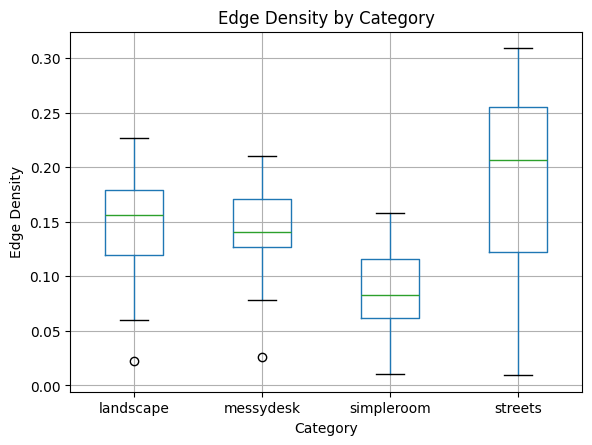

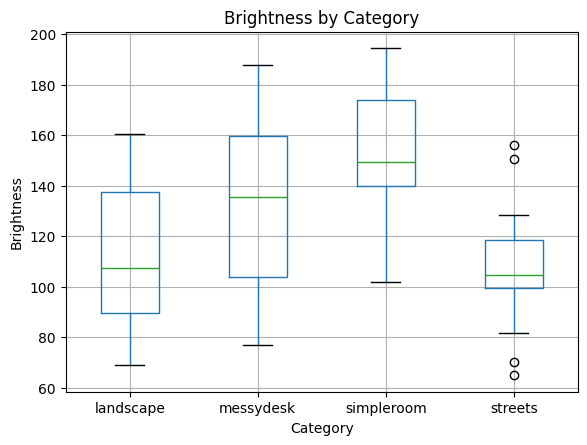

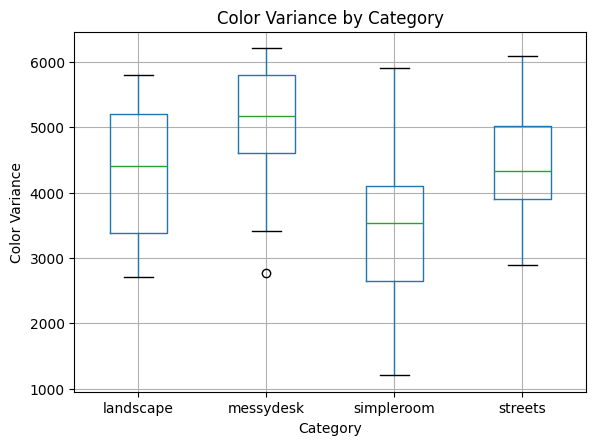

In [20]:
#boxplot of edge density
df.boxplot(column="edge_density", by="category")
plt.title("Edge Density by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Edge Density")
plt.show()

#boxplot of brightness
df.boxplot(column="brightness", by="category")
plt.title("Brightness by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Brightness")
plt.show()

#boxplot of color variance
df.boxplot(column="color_var", by="category")
plt.title("Color Variance by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Color Variance")
plt.show()

In [21]:
#edge density full stats
summary=df.groupby("category")["edge_density"].agg(["mean", "std", "min", "max", "count"])
print(summary)

                mean       std       min       max  count
category                                                 
landscape   0.147389  0.055097  0.022158  0.227175     20
messydesk   0.140796  0.047333  0.026010  0.210503     20
simpleroom  0.084717  0.039739  0.010618  0.157590     20
streets     0.185482  0.089015  0.009289  0.309091     20


In [22]:
#Categories ranked by edge density
ranked = means.sort_values(ascending=False)

print(ranked)

category
streets       0.185482
landscape     0.147389
messydesk     0.140796
simpleroom    0.084717
Name: edge_density, dtype: float64


In [23]:
#Difference between highest and lowest category
spread = means.max() - means.min()

print(spread)

0.10076547433428024


In [24]:
#Image with highest edge density
print(df.loc[df["edge_density"].idxmax()])

#Image with lowest edge density
print("\nLeast complex image:")
print(df.loc[df["edge_density"].idxmin()])

image                     streets11.jpg
category                        streets
edge_density                   0.309091
brightness                   116.383448
color_var                   4450.455345
researcher_complexity                 5
participant_complexity              4.0
Name: 34, dtype: object

Least complex image:
image                     streets2.jpg
category                       streets
edge_density                  0.009289
brightness                   64.864223
color_var                  2884.278008
researcher_complexity                3
participant_complexity             3.6
Name: 24, dtype: object


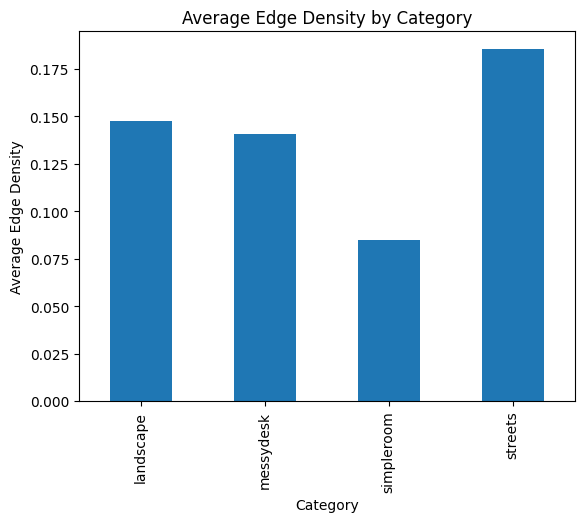

In [25]:
#Boxplot for average edge density by category
#edge density bar chart
means.plot(kind="bar")

plt.title("Average Edge Density by Category")
plt.xlabel("Category")
plt.ylabel("Average Edge Density")

plt.show()

## Week 1 Conclusions

During Week 1, I created a dataset of 80 images spanning four categories: messy desks, streets, landscapes, and simple rooms. For each image, I extracted three computational visual features:

- Edge density
- Average brightness
- Color variance

I also included two sets of complexity ratings:

- Researcher-assigned complexity ratings
- Participant average complexity ratings (averaged across five participants per image)

Exploratory analysis revealed clear differences across image categories. Street scenes had the highest average edge density (0.185), indicating they contained more detectable edges and visual detail than the other categories. Simple rooms had the lowest average edge density (0.085), indicating they were visually less detailed on average. Simple rooms also exhibited the highest average brightness, while messy desks showed the greatest average color variance.

The boxplots and summary statistics further illustrated the distributions of these features across categories, demonstrating that although categories differed on average, there was still substantial variation among individual images.

Overall, Week 1 successfully produced a clean dataset containing computational image features and human complexity ratings. This dataset serves as the foundation for the statistical analyses and machine learning models developed in the following weeks.